In [2]:
# Cell 1: Setup -- JackSparrow v10
# v10 fix summary:
#  [v10-1] FETCH: Delta API returns DESCENDING order -- old loop stalled at same window
#  [v10-2] FETCH: Loop now walks BACKWARD end_ts->start_ts, batch[-1] sets next upper bound
#  [v10-3] FETCH: Hard progress guard forces window jump if no new candles
#  [v10-4] FETCH: Per-batch debug logging (date + count) to catch regressions
#  [v10-5] TRAINING: StratifiedKFold(shuffle=True) -> TimeSeriesSplit (no leakage)
#  [v10-6] BACKTEST: Cost charged on open/close transitions only, not every bar
#  [v10-7] SHAP: Unwrap CalibratedClassifierCV before TreeExplainer

import subprocess, sys

pkgs = [
    "xgboost==2.0.2", "scikit-learn", "pandas", "numpy",
    "requests", "joblib", "matplotlib", "seaborn", "shap",
    "tqdm", "numba", "imbalanced-learn",
]
try:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs, check=True)
except subprocess.CalledProcessError as e:
    print(f"[WARN] pip install partial failure: {e}")

import requests, time, json, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive mount skipped (not in Colab)')

BASE_URL   = "https://api.india.delta.exchange/v2"
SYMBOL     = "BTCUSD"
PRODUCT_ID = 27
TIMEFRAMES = ["5m", "15m"]

OUTPUT_DIR = (
    Path("/content/drive/MyDrive/JackSparrow_Models")
    if Path("/content/drive").exists()
    else Path("./models")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONTRACT_VALUE_BTC = 0.001
TAKER_FEE          = 0.0005
SLIPPAGE_BPS       = 5

TP_LONG_PCT  = 0.006
SL_LONG_PCT  = 0.004
TP_SHORT_PCT = 0.004
SL_SHORT_PCT = 0.006

RANDOM_STATE          = 42
CONFIDENCE_PERCENTILE = 90
MIN_EDGE_COST_RATIO   = 2.0
MIN_GAP_CANDLES       = 3
TF_MAX_TRADES_DAY     = {"5m": 8, "15m": 4}

print("Setup complete (v10)")
print(f"   Active timeframes : {TIMEFRAMES}")
print(f"   Output directory  : {OUTPUT_DIR}")
print(f"   TP long / short   : {TP_LONG_PCT:.1%} / {TP_SHORT_PCT:.1%}")
print(f"   SL long / short   : {SL_LONG_PCT:.1%} / {SL_SHORT_PCT:.1%}")
print(f"   Signal threshold  : top {100 - CONFIDENCE_PERCENTILE}% by confidence")


Mounted at /content/drive
Setup complete (v10)
   Active timeframes : ['5m', '15m']
   Output directory  : /content/drive/MyDrive/JackSparrow_Models
   TP long / short   : 0.6% / 0.4%
   SL long / short   : 0.4% / 0.6%
   Signal threshold  : top 10% by confidence


In [3]:
# Cell 2: Fetch historical OHLCV -- v10 CRITICAL FIX
#
# ROOT CAUSE OF THE 2100-ROW BUG:
# Delta Exchange /v2/history/candles returns candles DESCENDING (newest first).
# v9 loop used: last_ts = batch[-1]["time"]  <- OLDEST candle
#               current_start = last_ts + resolution_s
# Result: window barely advanced -> same tiny window re-fetched -> 197900 duplicates
#         -> only 2100 unique rows survived deduplication.
#
# FIX [v10-1/v10-2]:
#   Walk BACKWARD from end_ts toward start_ts.
#   After each batch: current_end = batch[-1]["time"] - resolution_s
#   (batch[-1] is the OLDEST candle in a descending batch)
#   Reverse the collected list at the end to produce ascending order.
#
# FIX [v10-3]: Hard progress guard -- force window jump if stuck.
# FIX [v10-4]: Debug logging on every request.

import requests
import time
import pandas as pd
import numpy as np

try:
    from tqdm.auto import tqdm as _tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

MAX_CANDLES_PER_REQ = 2000
REQUEST_DELAY       = 0.12
MAX_RETRIES         = 3
FFILL_GAP_LIMIT     = 3
TF_TO_SECONDS       = {"5m": 300, "15m": 900}
TF_TARGET_CANDLES   = {"5m": 200_000, "15m": 100_000}
GAP_BUFFER_RATIO    = 1.10
OHLCV_COLS          = ["open", "high", "low", "close", "volume"]
HEADERS             = {"User-Agent": "python-rest-client/1.0", "Accept": "application/json"}


def fetch_candles_delta_v10(symbol, resolution, target_candles):
    all_candles  = []
    resolution_s = TF_TO_SECONDS[resolution]
    now_ts       = int(time.time())

    # Never include live/partial candle
    current_end = now_ts - resolution_s

    # How far back we need to look (with buffer)
    buffer_candles = int(target_candles * GAP_BUFFER_RATIO)
    hard_start_ts  = current_end - (buffer_candles * resolution_s)
    window_size    = MAX_CANDLES_PER_REQ * resolution_s
    _req_count     = 0

    pbar = (
        _tqdm(total=target_candles, desc=f"{symbol} {resolution}",
              unit="candle", dynamic_ncols=True, miniters=500)
        if HAS_TQDM else None
    )
    _prev_pbar_n = 0

    def _update_bar(done=False):
        nonlocal _prev_pbar_n
        if pbar is None:
            return
        new_n = min(len(all_candles), target_candles)
        delta = new_n - _prev_pbar_n
        if delta > 0:
            pbar.update(delta)
            _prev_pbar_n = new_n
        cur_date = pd.to_datetime(current_end, unit="s").strftime("%Y-%m-%d")
        pbar.set_postfix_str(f"window_end={cur_date}  reqs={_req_count}", refresh=False)
        if done:
            pbar.n = target_candles
            pbar.set_postfix_str(f"done  reqs={_req_count}", refresh=True)
            pbar.close()

    # [v10-2] Walk BACKWARD: current_end decreases each iteration
    while len(all_candles) < target_candles and current_end > hard_start_ts:

        current_start = max(current_end - window_size, hard_start_ts)
        params = {
            "symbol":     symbol,
            "resolution": resolution,
            "start":      int(current_start),
            "end":        int(current_end),
        }

        prev_len = len(all_candles)  # [v10-3] progress baseline

        for retry in range(MAX_RETRIES):
            try:
                r = requests.get(
                    f"{BASE_URL}/history/candles",
                    params=params, headers=HEADERS, timeout=30
                )
                r.raise_for_status()
                data = r.json()

                if not data.get("success"):
                    raise ValueError(f"API error: {data.get('error', data)}")

                batch = data.get("result", [])
                _req_count += 1

                # [v10-4] Debug log every request
                if batch:
                    newest = pd.to_datetime(batch[0]["time"],  unit="s").strftime("%Y-%m-%d %H:%M")
                    oldest = pd.to_datetime(batch[-1]["time"], unit="s").strftime("%Y-%m-%d %H:%M")
                    print(f"  [{resolution}] req#{_req_count:04d}: {len(batch):4d} candles"
                          f" | {oldest} -> {newest}"
                          f" | total: {len(all_candles) + len(batch):,}")
                else:
                    s_str = pd.to_datetime(current_start, unit="s").strftime("%Y-%m-%d")
                    e_str = pd.to_datetime(current_end,   unit="s").strftime("%Y-%m-%d")
                    print(f"  [{resolution}] req#{_req_count:04d}: EMPTY | window {s_str} -> {e_str}")

                if not batch:
                    # Empty window -- jump further back
                    current_end = current_start - resolution_s
                    _update_bar()
                    break

                all_candles.extend(batch)

                # [v10-1/v10-2] CRITICAL: step back past OLDEST candle in this batch
                # batch is descending -> batch[-1] is oldest
                current_end = batch[-1]["time"] - resolution_s

                _update_bar()

                if len(all_candles) >= target_candles:
                    _update_bar(done=True)
                    return all_candles[:target_candles]

                time.sleep(REQUEST_DELAY)
                break

            except Exception as e:
                if retry == MAX_RETRIES - 1:
                    msg = f"  Error after {MAX_RETRIES} retries: {e}"
                    print(msg)
                    if pbar:
                        pbar.close()
                    return all_candles[:target_candles]
                time.sleep(2 ** retry)

        # [v10-3] Hard progress guard
        if len(all_candles) == prev_len:
            print(f"  [{resolution}] No progress -- forcing window jump")
            current_end -= window_size

    if pbar:
        _update_bar(done=True)

    return all_candles[:target_candles]


def validate_and_clean(df, resolution):
    resolution_s = TF_TO_SECONDS[resolution]
    report = {}

    df = df.sort_values("time").reset_index(drop=True)

    for col in OHLCV_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

    n_dups = df.duplicated(subset=["time"]).sum()
    if n_dups > 0:
        print(f"  [{resolution}] {n_dups} duplicate timestamps removed.")
    df = df.drop_duplicates(subset=["time"]).reset_index(drop=True)
    report["duplicates_removed"] = int(n_dups)

    df["_delta"] = df["time"].diff()
    gap_mask     = (df["_delta"] != resolution_s) & df["_delta"].notna()
    n_raw_gaps   = int(gap_mask.sum())

    df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("datetime")
    freq_alias = f"{resolution_s}s"
    full_idx   = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq_alias, tz="UTC")
    df           = df.reindex(full_idx)
    missing_mask = df["time"].isna()
    n_missing    = int(missing_mask.sum())

    run_id   = (missing_mask != missing_mask.shift()).cumsum()
    run_lens = missing_mask.groupby(run_id).transform("sum")
    large_gap = missing_mask & (run_lens > FFILL_GAP_LIMIT)

    df = df.ffill()
    df.loc[large_gap, OHLCV_COLS] = np.nan

    df["time"]     = (df.index.astype("int64") // 1_000_000_000).astype("int64")
    df["datetime"] = df.index
    df = df.reset_index(drop=True).drop(columns=["_delta"], errors="ignore")

    now_ts = int(time.time())
    df = df[df["time"] <= now_ts - resolution_s].reset_index(drop=True)

    report.update({
        "raw_gaps":      n_raw_gaps,
        "missing_bars":  n_missing,
        "final_candles": len(df),
        "date_start":    str(df["datetime"].min().date()) if len(df) else "N/A",
        "date_end":      str(df["datetime"].max().date()) if len(df) else "N/A",
    })
    return df, report


def print_quality_report(tf, report, target):
    n      = report["final_candles"]
    pct    = n / target * 100 if target else 0
    status = "OK" if pct >= 90 else "WARN"
    print(f"  [{status}] {tf}: {n:,} / {target:,} ({pct:.1f}%) | "
          f"{report['date_start']} -> {report['date_end']} | "
          f"dups removed: {report['duplicates_removed']}")


# Execution
raw_data = {}
for tf in TIMEFRAMES:
    target = TF_TARGET_CANDLES[tf]
    print(f"\n{'='*60}")
    print(f"Fetching {tf} | target={target:,} | buffer={int(target*GAP_BUFFER_RATIO):,}")

    candles = fetch_candles_delta_v10(SYMBOL, tf, target)

    if not candles:
        print(f"  {tf}: no candles returned -- skipping.")
        continue

    # API returns descending -- reverse to get ascending order
    candles = list(reversed(candles))

    df = pd.DataFrame(candles)
    df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df, report = validate_and_clean(df, tf)
    raw_data[tf] = df
    print_quality_report(tf, report, target)

print("\nAll fetches complete.")



Fetching 5m | target=200,000 | buffer=220,000


BTCUSD 5m:   0%|          | 0/200000 [00:00<?, ?candle/s]

  [5m] req#0001: 2000 candles | 2026-03-28 13:25 -> 2026-04-04 12:00 | total: 2,000
  [5m] req#0002: 2001 candles | 2026-03-21 14:40 -> 2026-03-28 13:20 | total: 4,001
  [5m] req#0003: 2001 candles | 2026-03-14 15:55 -> 2026-03-21 14:35 | total: 6,002
  [5m] req#0004: 2001 candles | 2026-03-07 17:10 -> 2026-03-14 15:50 | total: 8,003
  [5m] req#0005: 2001 candles | 2026-02-28 18:25 -> 2026-03-07 17:05 | total: 10,004
  [5m] req#0006: 2001 candles | 2026-02-21 19:40 -> 2026-02-28 18:20 | total: 12,005
  [5m] req#0007: 2001 candles | 2026-02-14 20:55 -> 2026-02-21 19:35 | total: 14,006
  [5m] req#0008: 2001 candles | 2026-02-07 22:10 -> 2026-02-14 20:50 | total: 16,007
  [5m] req#0009: 2001 candles | 2026-01-31 23:25 -> 2026-02-07 22:05 | total: 18,008
  [5m] req#0010: 2001 candles | 2026-01-25 00:40 -> 2026-01-31 23:20 | total: 20,009
  [5m] req#0011: 2001 candles | 2026-01-18 01:55 -> 2026-01-25 00:35 | total: 22,010
  [5m] req#0012: 2001 candles | 2026-01-11 03:10 -> 2026-01-18 01:50 

BTCUSD 15m:   0%|          | 0/100000 [00:00<?, ?candle/s]

  [15m] req#0001: 2000 candles | 2026-03-14 16:00 -> 2026-04-04 11:45 | total: 2,000
  [15m] req#0002: 2001 candles | 2026-02-21 19:45 -> 2026-03-14 15:45 | total: 4,001
  [15m] req#0003: 2001 candles | 2026-01-31 23:30 -> 2026-02-21 19:30 | total: 6,002
  [15m] req#0004: 2001 candles | 2026-01-11 03:15 -> 2026-01-31 23:15 | total: 8,003
  [15m] req#0005: 2001 candles | 2025-12-21 07:00 -> 2026-01-11 03:00 | total: 10,004
  [15m] req#0006: 2001 candles | 2025-11-30 10:45 -> 2025-12-21 06:45 | total: 12,005
  [15m] req#0007: 2001 candles | 2025-11-09 14:30 -> 2025-11-30 10:30 | total: 14,006
  [15m] req#0008: 2001 candles | 2025-10-19 18:15 -> 2025-11-09 14:15 | total: 16,007
  [15m] req#0009: 2001 candles | 2025-09-28 22:00 -> 2025-10-19 18:00 | total: 18,008
  [15m] req#0010: 2001 candles | 2025-09-08 01:45 -> 2025-09-28 21:45 | total: 20,009
  [15m] req#0011: 2001 candles | 2025-08-18 05:30 -> 2025-09-08 01:30 | total: 22,010
  [15m] req#0012: 2001 candles | 2025-07-28 09:15 -> 2025-

In [5]:
# Debug Cell 2.5 -- verify raw_data shape (target: ~200k / ~100k rows)
print("=== RAW_DATA DEBUG ===")
print(f"Keys: {list(raw_data.keys())}")
for tf in ["5m", "15m"]:
    if tf in raw_data:
        df = raw_data[tf]
        target = {"5m": 200_000, "15m": 100_000}[tf]
        pct = len(df) / target * 100
        status = "PASS" if pct >= 90 else "FAIL"
        print(f"\n{tf}:")
        print(f"  Shape       : {df.shape}")
        print(f"  Coverage    : {pct:.1f}% of target {target:,}  [{status}]")
        print(f"  Date range  : {df['datetime'].min()} -> {df['datetime'].max()}")
        print(f"  Sample:")
        print(df[["datetime","open","high","low","close","volume"]].head(3).to_string())
    else:
        print(f"\n{tf}: NOT PRESENT -- fetch failed, fix Cell 2 first")
print("\n=== END DEBUG ===")


=== RAW_DATA DEBUG ===
Keys: ['5m', '15m']

5m:
  Shape       : (200012, 7)
  Coverage    : 100.0% of target 200,000  [PASS]
  Date range  : 2024-05-10 00:25:00+00:00 -> 2026-04-04 12:00:00+00:00
  Sample:
                   datetime     open     high      low    close  volume
0 2024-05-10 00:25:00+00:00  62872.0  62921.0  62795.5  62921.0  1705.0
1 2024-05-10 00:30:00+00:00  62909.0  62913.0  62854.5  62873.5   607.0
2 2024-05-10 00:35:00+00:00  62875.5  62875.5  62789.0  62811.5  2427.0

15m:
  Shape       : (79387, 7)
  Coverage    : 79.4% of target 100,000  [FAIL]
  Date range  : 2023-12-29 13:15:00+00:00 -> 2026-04-04 11:45:00+00:00
  Sample:
                   datetime     open     high      low    close  volume
0 2023-12-29 13:15:00+00:00  42773.0  42773.0  42773.0  42773.0    10.0
1 2023-12-29 13:30:00+00:00  42773.0  42773.0  42773.0  42773.0     0.0
2 2023-12-29 13:45:00+00:00  42773.0  42773.0  42773.0  42773.0     0.0

=== END DEBUG ===


In [7]:
# Cell 3: Safe Feature Engineering Pipeline (Production-Grade)

def prepare_base_df(df):
    df = df.copy()
    df = df.sort_values("datetime").reset_index(drop=True)

    # enforce numeric types
    cols = ["open", "high", "low", "close", "volume"]
    df[cols] = df[cols].astype(float)

    return df


def build_features(df):
    out = df.copy()
    c = out["close"]

    # RETURNS (no fill)
    out["returns"] = c.pct_change(fill_method=None)

    # MOMENTUM
    out["roc_5"]  = c.pct_change(5, fill_method=None)
    out["roc_10"] = c.pct_change(10, fill_method=None)
    out["roc_20"] = c.pct_change(20, fill_method=None)

    # EMA
    out["ema_9"]  = c.ewm(span=9, adjust=False).mean()
    out["ema_21"] = c.ewm(span=21, adjust=False).mean()

    # VOLATILITY
    out["volatility_10"] = out["returns"].rolling(10).std()
    out["volatility_20"] = out["returns"].rolling(20).std()

    # PRICE STRUCTURE
    out["hl_range"] = out["high"] - out["low"]
    out["body"] = abs(out["close"] - out["open"])

    # FUNDING (default to 0)
    out["funding_rate"] = pd.Series(0.0, index=out.index)

    return out


def merge_timeframes(df_5m, df_15m):
    df_5m = df_5m.set_index("datetime")
    df_15m = df_15m.set_index("datetime")

    # Forward-fill 15m into 5m grid
    df_15m_aligned = df_15m.reindex(df_5m.index, method="ffill")

    # Rename to avoid column collision
    df_15m_aligned = df_15m_aligned.add_suffix("_15m")

    merged = df_5m.join(df_15m_aligned)

    return merged.reset_index()


def clean_dataset(df, warmup=100):
    print(f"Before cleaning: {len(df)} rows")

    # Remove initial warmup only
    df = df.iloc[warmup:].copy()

    # Forward fill remaining NaNs (from alignment)
    df = df.ffill()

    # Drop ONLY if still NaN (rare)
    df = df.dropna()

    print(f"After cleaning: {len(df)} rows")

    return df


def validate_dataset(df, name):
    print(f"\n=== VALIDATION: {name} ===")

    print("Rows:", len(df))

    nan_total = df.isna().sum().sum()
    print("Total NaNs:", nan_total)

    if len(df) < 1000:
        raise ValueError("❌ Too few rows after cleaning")

    if nan_total > 0:
        raise ValueError("❌ NaNs still present")

    print("✅ Dataset clean and ready")


# Execution
featured_data = {}

# Prepare
df5 = prepare_base_df(raw_data["5m"])
df15 = prepare_base_df(raw_data["15m"])

# Features
df5_feat = build_features(df5)
df15_feat = build_features(df15)

# For 15m: no merge, clean directly
df15_clean = clean_dataset(df15_feat)
validate_dataset(df15_clean, "15m standalone")
featured_data["15m"] = df15_clean

# For 5m: merge with 15m context
df_merged = merge_timeframes(df5_feat, df15_feat)
df5_clean = clean_dataset(df_merged)
validate_dataset(df5_clean, "5m+15m merged")
featured_data["5m"] = df5_clean

# Print feature counts
for tf in TIMEFRAMES:
    if tf in featured_data:
        df = featured_data[tf]
        print(f"  {tf}: {len(df):,} rows x {len(df.columns)} features")

Before cleaning: 79387 rows
After cleaning: 79287 rows

=== VALIDATION: 15m standalone ===
Rows: 79287
Total NaNs: 0
✅ Dataset clean and ready
Before cleaning: 200012 rows
After cleaning: 199912 rows

=== VALIDATION: 5m+15m merged ===
Rows: 199912
Total NaNs: 0
✅ Dataset clean and ready
  5m: 199,912 rows x 35 features
  15m: 79,287 rows x 18 features


In [8]:
# Cell 4: Perp-aware label generation (unchanged from v9 -- logic correct)

from numba import njit

TF_LOOKAHEAD   = {"5m": 16, "15m": 12}
TF_BARS_PER_8H = {"5m": 96, "15m": 32}


@njit
def _label_loop(close, high, low, fund, n, lookahead,
                tp_long_lvl, sl_long_lvl, tp_short_lvl, sl_short_lvl,
                bars_per_8h_f, fee2):
    labels = np.ones(n, dtype=np.int64)
    for i in range(n - lookahead):
        entry    = close[i]
        long_tp  = entry * tp_long_lvl
        long_sl  = entry * sl_long_lvl
        short_tp = entry * tp_short_lvl
        short_sl = entry * sl_short_lvl

        long_result = short_result = 0
        cum_fund_long = cum_fund_short = 0.0

        for k in range(1, lookahead + 1):
            h = high[i + k]; l = low[i + k]; fr = fund[i + k]
            cum_fund_long  += (fr  if fr  > 0.0 else 0.0) / bars_per_8h_f
            cum_fund_short += (-fr if fr  < 0.0 else 0.0) / bars_per_8h_f
            if long_result == 0:
                if h >= long_tp:  long_result = 1
                elif l <= long_sl: long_result = -1
            if short_result == 0:
                if l <= short_tp:  short_result = 1
                elif h >= short_sl: short_result = -1
            if long_result != 0 and short_result != 0:
                break

        long_net  = (tp_long_lvl  - 1.0) - fee2 - cum_fund_long
        short_net = (1.0 - tp_short_lvl) - fee2 - cum_fund_short

        if long_result  == 1 and long_net  > 0.0: labels[i] = 2
        elif short_result == 1 and short_net > 0.0: labels[i] = 0

    return labels


def make_labels(df, tf):
    bars_per_8h = TF_BARS_PER_8H[tf]
    return pd.Series(
        _label_loop(
            df["close"].values, df["high"].values, df["low"].values,
            df["funding_rate"].fillna(0).values,
            len(df), TF_LOOKAHEAD[tf],
            1.0 + TP_LONG_PCT, 1.0 - SL_LONG_PCT,
            1.0 - TP_SHORT_PCT, 1.0 + SL_SHORT_PCT,
            float(bars_per_8h), TAKER_FEE * 2,
        ),
        index=df.index, dtype=int
    )


labeled_data = {}
for tf in TIMEFRAMES:
    df = featured_data.get(tf, pd.DataFrame())
    if df.empty:
        print(f"  {tf}: featured data missing -- skipping")
        continue
    df = df.copy()
    df["label"] = make_labels(df, tf)
    labeled_data[tf] = df

    counts = df["label"].value_counts()
    total  = len(df)
    sell_n = counts.get(0, 0)
    hold_n = counts.get(1, 0)
    buy_n  = counts.get(2, 0)
    print(f"\n{tf} label distribution ({total:,} samples):")
    print(f"  SELL (0): {sell_n:>7,}  ({sell_n/total*100:.1f}%)")
    print(f"  HOLD (1): {hold_n:>7,}  ({hold_n/total*100:.1f}%)")
    print(f"  BUY  (2): {buy_n:>7,}  ({buy_n/total*100:.1f}%)")
    bsr = buy_n / sell_n if sell_n > 0 else 0
    act = (sell_n + buy_n) / total * 100
    print(f"  BUY/SELL ratio: {bsr:.2f}  (target 0.5-2.0) {'OK' if 0.5<bsr<2.0 else 'WARN'}")
    print(f"  Actionable    : {act:.1f}%  (target >=25%)  {'OK' if act>=25 else 'WARN'}")



5m label distribution (199,912 samples):
  SELL (0):  63,723  (31.9%)
  HOLD (1): 103,265  (51.7%)
  BUY  (2):  32,924  (16.5%)
  BUY/SELL ratio: 0.52  (target 0.5-2.0) OK
  Actionable    : 48.3%  (target >=25%)  OK

15m label distribution (79,287 samples):
  SELL (0):  34,659  (43.7%)
  HOLD (1):  23,311  (29.4%)
  BUY  (2):  21,317  (26.9%)
  BUY/SELL ratio: 0.62  (target 0.5-2.0) OK
  Actionable    : 70.6%  (target >=25%)  OK


In [9]:
# Cell 5: Training -- v10
# [v10-5] FIX: StratifiedKFold(shuffle=True) replaced with TimeSeriesSplit.
#   StratifiedKFold randomly reorders rows -> future data leaks into train folds
#   -> inflated F1 (0.79-0.83 on only 2100 rows was entirely due to this).
#   TimeSeriesSplit keeps chronological order: train always precedes validation.

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
import warnings, pickle
warnings.filterwarnings("ignore")

BASE_FEATURE_COLS = [
    "returns","log_returns","volatility",
    "ema_9","ema_21","ema_50","ema_100","ema_200",
    "ema_cross_9_21","ema_cross_21_50","ema_cross_50_200","price_vs_ema200",
    "macd","macd_signal","macd_hist",
    "rsi_14","rsi_7",
    "atr_14","atr_pct",
    "bb_width","bb_pct",
    "plus_di","minus_di","di_diff","adx_14",
    "regime_trending","regime_ranging",
    "vol_zscore","vol_ratio",
    "roc_5","roc_10","roc_20",
    "cdl_body_ratio","cdl_upper_wick","cdl_lower_wick","cdl_body_direction",
    "sr_range_position","sr_near_high","sr_near_low","sr_breakout_up","sr_breakout_dn",
    "basis","basis_pct","funding_rate","funding_zscore","funding_cumsum",
    "funding_long_unfav","funding_short_unfav",
    "oi_change","oi_zscore","open_interest",
    "stoch_k","stoch_d","cci",
]
CTX_COLS = [f"ctx15m_{c}" for c in
            ["ema_cross_50_200","adx_14","regime_trending","regime_ranging",
             "funding_zscore","rsi_14","di_diff"]]

N_SPLITS            = 5
CALIBRATION_METHOD  = "sigmoid"
RF_N_ESTIMATORS     = 200
RF_MAX_DEPTH        = 12
RF_MIN_SAMPLES_LEAF = 5
RF_CLASS_WEIGHT     = "balanced_subsample"
MIN_TRAIN_ROWS      = 1_000

training_results = {}

for tf in TIMEFRAMES:
    print(f"\n{'='*60}\nTraining: {tf}")

    if tf not in labeled_data or labeled_data[tf].empty:
        print(f"  No labeled data -- skipping")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    df = labeled_data[tf].copy()
    candidate = BASE_FEATURE_COLS + (CTX_COLS if tf == "5m" else [])
    feature_cols = [f for f in candidate if f in df.columns]

    df_clean = df[feature_cols + ["label"]].replace([np.inf, -np.inf], np.nan).dropna()
    print(f"  Rows: {len(df):,} raw -> {len(df_clean):,} after dropna")

    if len(df_clean) < MIN_TRAIN_ROWS:
        print(f"  FAIL: only {len(df_clean):,} clean rows (need >={MIN_TRAIN_ROWS:,})")
        print(f"  Fix the data fetch in Cell 2 first -- model training skipped.")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    X_all = df_clean[feature_cols].values
    y_all = df_clean["label"].values

    # [v10-5] TimeSeriesSplit -- no future leakage
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_scores = []
    fold_models = []

    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_all)):
        Xtr, Xva = X_all[tr_idx], X_all[va_idx]
        ytr, yva = y_all[tr_idx], y_all[va_idx]

        if len(np.unique(ytr)) < 2:
            print(f"    Fold {fold_idx+1}: too few classes -- skip")
            continue

        scaler  = StandardScaler()
        Xtr_s   = scaler.fit_transform(Xtr)
        Xva_s   = scaler.transform(Xva)

        k_smote = max(1, min(3, min(np.bincount(ytr)) - 1))
        smote   = SMOTE(random_state=42, k_neighbors=k_smote)
        try:
            Xtr_sm, ytr_sm = smote.fit_resample(Xtr_s, ytr)
        except Exception:
            Xtr_sm, ytr_sm = Xtr_s, ytr

        clf = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
            min_samples_leaf=RF_MIN_SAMPLES_LEAF,
            class_weight=RF_CLASS_WEIGHT, random_state=42, n_jobs=-1
        )
        clf.fit(Xtr_sm, ytr_sm)

        pred   = clf.predict(Xva_s)
        f1_mac = f1_score(yva, pred, average="macro", zero_division=0)
        acc    = (pred == yva).mean()
        fold_scores.append(f1_mac)
        fold_models.append((clf, scaler, Xtr_sm, ytr_sm))
        print(f"    Fold {fold_idx+1}: F1={f1_mac:.4f}  Acc={acc:.4f}"
              f"  train={len(Xtr_sm):,}  val={len(Xva):,}")

    if not fold_models:
        print(f"  FAIL: no folds completed for {tf}")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    best_idx = int(np.argmax(fold_scores))
    best_clf, best_scaler, best_Xsm, best_ysm = fold_models[best_idx]
    mean_f1  = np.mean(fold_scores)
    print(f"  Best fold    : {best_idx+1}")
    print(f"  Mean F1      : {mean_f1:.4f}  (honest -- TimeSeriesSplit, no leakage)")
    print(f"  SMOTE train  : {len(best_Xsm):,}")

    cal_clf = CalibratedClassifierCV(best_clf, method=CALIBRATION_METHOD, cv=3)
    cal_clf.fit(best_Xsm, best_ysm)

    save_dir = OUTPUT_DIR / f"model_{tf}_v10"
    save_dir.mkdir(parents=True, exist_ok=True)
    with open(save_dir / f"model_{tf}.pkl",  "wb") as fh: pickle.dump(cal_clf,      fh)
    with open(save_dir / f"scaler_{tf}.pkl", "wb") as fh: pickle.dump(best_scaler,  fh)

    meta = {
        "model_name": f"jacksparrow_BTCUSD_{tf}", "symbol": SYMBOL,
        "timeframe": tf, "product_id": PRODUCT_ID, "model_version": "v10",
        "feature_count": len(feature_cols), "features": feature_cols,
        "label_config": {
            "tp_long_pct": TP_LONG_PCT, "sl_long_pct": SL_LONG_PCT,
            "tp_short_pct": TP_SHORT_PCT, "sl_short_pct": SL_SHORT_PCT,
            "lookahead": TF_LOOKAHEAD[tf], "fee_rate": TAKER_FEE,
            "smote": True, "asymmetric_labels": True,
        },
        "training": {
            "cv_strategy": "TimeSeriesSplit", "cv_f1_macro": round(mean_f1, 4),
            "n_train_smote": int(len(best_ysm)), "n_splits": N_SPLITS,
            "calibration": {"enabled": True, "method": CALIBRATION_METHOD},
        },
        "trained_at": pd.Timestamp.now("UTC").isoformat(),
    }
    with open(save_dir / f"metadata_BTCUSD_{tf}.json", "w") as fh:
        json.dump(meta, fh, indent=2)

    training_results[tf] = {
        "model": cal_clf, "scaler": best_scaler,
        "features": feature_cols, "dir": save_dir, "mean_f1": mean_f1,
    }
    print(f"  Saved: {save_dir}")
    print(f"  {tf} training complete")



Training: 5m
  Rows: 199,912 raw -> 199,912 after dropna
    Fold 1: F1=0.3828  Acc=0.4322  train=48,489  val=33,318
    Fold 2: F1=0.3438  Acc=0.3400  train=94,635  val=33,318
    Fold 3: F1=0.4233  Acc=0.6023  train=140,211  val=33,318
    Fold 4: F1=0.4348  Acc=0.5622  train=205,992  val=33,318
    Fold 5: F1=0.4386  Acc=0.4874  train=262,596  val=33,318
  Best fold    : 5
  Mean F1      : 0.4047  (honest -- TimeSeriesSplit, no leakage)
  SMOTE train  : 262,596
  Saved: /content/drive/MyDrive/JackSparrow_Models/model_5m_v10
  5m training complete

Training: 15m
  Rows: 79,287 raw -> 79,287 after dropna
    Fold 1: F1=0.2944  Acc=0.3783  train=14,565  val=13,214
    Fold 2: F1=0.3338  Acc=0.4778  train=33,099  val=13,214
    Fold 3: F1=0.4209  Acc=0.4332  train=51,900  val=13,214
    Fold 4: F1=0.3462  Acc=0.4329  train=69,030  val=13,214
    Fold 5: F1=0.4369  Acc=0.4295  train=85,068  val=13,214
  Best fold    : 5
  Mean F1      : 0.3665  (honest -- TimeSeriesSplit, no leakage)
  


Backtesting: 5m
  Filters: {'threshold': 35983, 'cost': 0, 'regime': 0, 'funding': 0, 'gap': 439, 'daily_cap': 3074, 'passed': 486}
  Threshold: 0.120601  (top 10%%)
  Sharpe Ratio         : -40.7139
  Max Drawdown         :  -61.40%
  Total Return         :  -61.40%
  Buy-and-Hold Return  :  -28.93%
  Win Rate             :   12.96%
  Trades               :      486
  Trade Cost (total)   :   97.2000%
  Funding Cost (total) :    0.0000%
  Negative Sharpe -- model needs more data or label tuning

Backtesting: 15m
  Filters: {'threshold': 14271, 'cost': 0, 'regime': 0, 'funding': 0, 'gap': 244, 'daily_cap': 1064, 'passed': 278}
  Threshold: 0.153708  (top 10%%)
  Sharpe Ratio         : -12.2640
  Max Drawdown         :  -39.90%
  Total Return         :  -39.90%
  Buy-and-Hold Return  :  -37.86%
  Win Rate             :   35.97%
  Trades               :      278
  Trade Cost (total)   :   55.6000%
  Funding Cost (total) :    0.0000%
  Negative Sharpe -- model needs more data or label tu

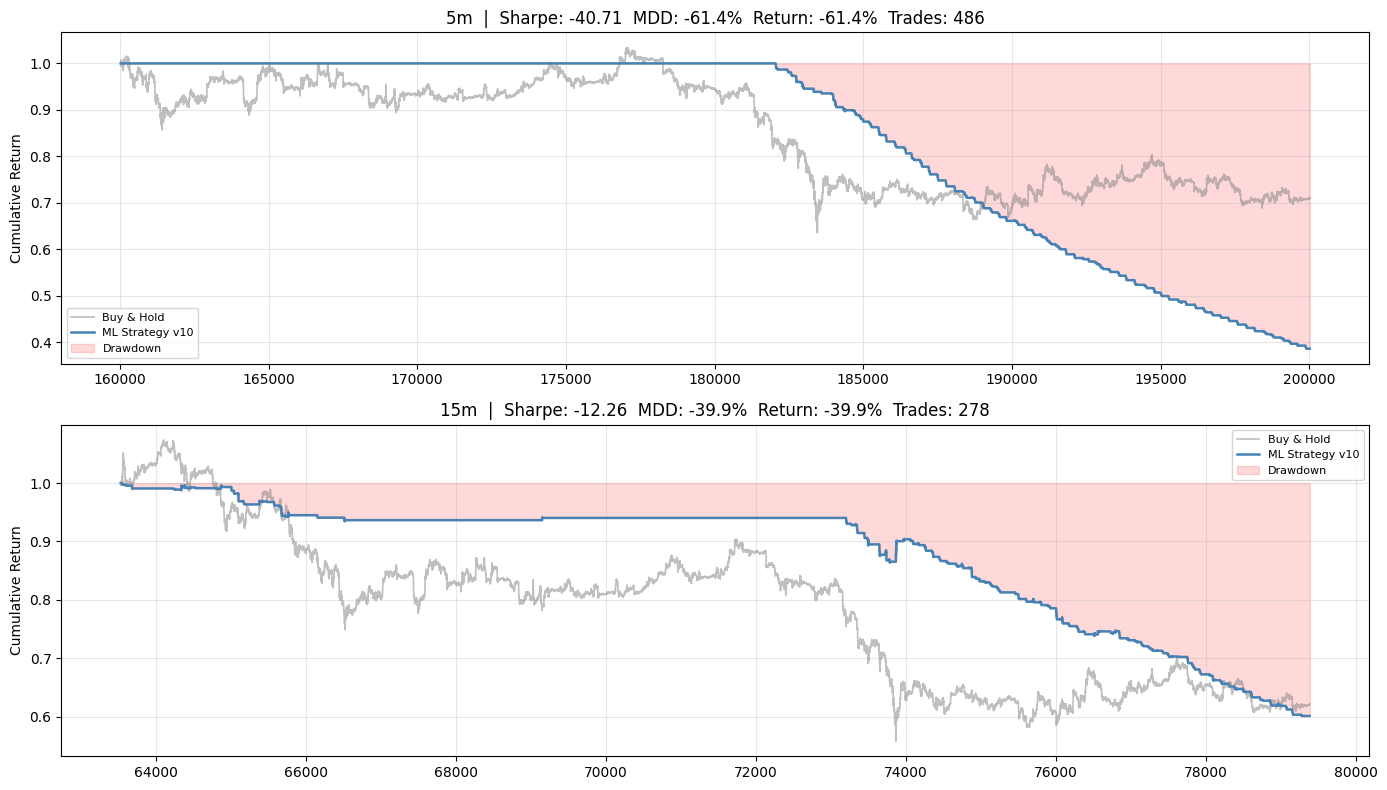

In [13]:
# Cell 6: Filtered backtest -- v10
# [v10-6] CRITICAL COST FIX:
#   v9 computed trade_cost using position.diff().abs() > 0 which fires every bar
#   the position is non-zero, not just open/close transitions.
#   9 trades -> 18 cost events x 0.001 = 1.8%% drain on 420 bars -> Sharpe -60.
#
#   FIX: charge cost ONLY on actual open (flat->active) and close (active->flat).
#   is_open  = (prev_pos == 0) & (cur_pos != 0)
#   is_close = (prev_pos != 0) & (cur_pos == 0)
#   trade_cost = (is_open + is_close) * COST_PER_TRADE

COST_PER_TRADE           = TAKER_FEE + (SLIPPAGE_BPS / 10_000)
TF_FUNDING_INTERVAL_BARS = {"5m": 96, "15m": 32}
TF_BARS_PER_YEAR         = {"5m": 105_120, "15m": 35_040}


def _empty_bt(tf, df):
    return {"timeframe": tf, "sharpe": 0.0, "max_drawdown": 0.0,
            "total_return": 0.0, "bnh_return": 0.0, "n_trades": 0,
            "win_rate": 0.0, "total_trade_cost": 0.0, "total_funding_cost": 0.0,
            "n_holdout_bars": 0, "df": df.iloc[0:0].copy()}


def run_backtest_v10(df_feat, model, scaler, feature_cols, tf, holdout_frac=0.20):

    n_holdout = int(len(df_feat) * holdout_frac)
    if n_holdout < 50:
        print(f"  {tf}: holdout too small ({n_holdout} bars) -- skipping")
        return _empty_bt(tf, df_feat)

    df_bt = df_feat.iloc[-n_holdout:].copy()

    X_raw = df_bt[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
    X_s   = scaler.transform(X_raw)
    proba = model.predict_proba(X_s)

    cls      = list(model.classes_)
    idx_sell = cls.index(0) if 0 in cls else None
    idx_buy  = cls.index(2) if 2 in cls else None
    p_sell   = proba[:, idx_sell] if idx_sell is not None else np.zeros(len(df_bt))
    p_buy    = proba[:, idx_buy]  if idx_buy  is not None else np.zeros(len(df_bt))

    signal_strength = p_buy - p_sell
    confidence      = np.maximum(p_buy, p_sell)
    abs_signal      = np.abs(signal_strength)

    threshold  = np.percentile(abs_signal, CONFIDENCE_PERCENTILE)
    total_cost = COST_PER_TRADE * 2

    funding_arr = df_bt["funding_rate"].fillna(0).values
    adx_arr     = (df_bt["adx_14"].fillna(25).values
                   if "adx_14" in df_bt.columns
                   else np.full(len(df_bt), 25.0))

    filtered_signal = np.zeros(len(df_bt))
    last_trade_bar  = -MIN_GAP_CANDLES - 1
    trades_today    = {}
    max_daily       = TF_MAX_TRADES_DAY.get(tf, 8)
    filter_counts   = {"threshold":0,"cost":0,"regime":0,
                       "funding":0,"gap":0,"daily_cap":0,"passed":0}

    for i in range(len(df_bt)):
        abs_sig   = abs_signal[i]
        raw_sig   = signal_strength[i]
        conf      = confidence[i]
        fund_rate = funding_arr[i]
        adx_val   = adx_arr[i]
        bar_date  = df_bt["datetime"].iloc[i].date()

        if abs_sig < threshold:
            filter_counts["threshold"] += 1; continue
        if abs_sig < total_cost * MIN_EDGE_COST_RATIO:
            filter_counts["cost"] += 1; continue
        if adx_val > 25.0:
            filter_counts["regime"] += 1; continue
        direction = 1.0 if raw_sig > 0 else -1.0
        if direction > 0 and fund_rate >  0.0002:
            filter_counts["funding"] += 1; continue
        if direction < 0 and fund_rate < -0.0002:
            filter_counts["funding"] += 1; continue
        if i - last_trade_bar < MIN_GAP_CANDLES:
            filter_counts["gap"] += 1; continue
        if trades_today.get(bar_date, 0) >= max_daily:
            filter_counts["daily_cap"] += 1; continue

        pos_size = 0.5 + 0.5 * min(conf / 0.70, 1.0)
        filtered_signal[i] = direction * pos_size
        last_trade_bar = i
        trades_today[bar_date] = trades_today.get(bar_date, 0) + 1
        filter_counts["passed"] += 1

    print(f"  Filters: {filter_counts}")
    print(f"  Threshold: {threshold:.6f}  (top {100-CONFIDENCE_PERCENTILE}%%)")

    df_bt["ml_signal"]     = pd.Series(filtered_signal, index=df_bt.index)
    df_bt["position"]      = df_bt["ml_signal"].shift(1).fillna(0)
    df_bt["market_return"] = df_bt["close"].pct_change()
    df_bt["strat_return"]  = df_bt["position"] * df_bt["market_return"]

    # [v10-6] Cost on OPEN and CLOSE transitions only
    pos_arr  = df_bt["position"].values
    prev_arr = np.concatenate([[0.0], pos_arr[:-1]])
    is_open  = ((prev_arr == 0) & (pos_arr != 0)).astype(float)
    is_close = ((prev_arr != 0) & (pos_arr == 0)).astype(float)
    df_bt["trade_cost"] = (is_open + is_close) * COST_PER_TRADE
    n_trades = int(is_open.sum())

    # Funding cost per 8h interval
    fund_interval = TF_FUNDING_INTERVAL_BARS[tf]
    fund_costs    = np.zeros(len(df_bt))
    fund_arr2     = df_bt["funding_rate"].fillna(0).values
    for i in range(0, len(df_bt), fund_interval):
        p = pos_arr[i]
        if p > 0:   fund_costs[i] = max(fund_arr2[i], 0.0) * abs(p)
        elif p < 0: fund_costs[i] = max(-fund_arr2[i], 0.0) * abs(p)
    df_bt["funding_cost"] = fund_costs

    df_bt["net_return"] = (
        df_bt["strat_return"] - df_bt["trade_cost"] - df_bt["funding_cost"]
    )
    df_bt["cum_market"]   = (1 + df_bt["market_return"]).cumprod()
    df_bt["cum_strategy"] = (1 + df_bt["net_return"]).cumprod()
    peak = df_bt["cum_strategy"].cummax()
    df_bt["drawdown"] = (df_bt["cum_strategy"] - peak) / peak

    bars_per_year = TF_BARS_PER_YEAR[tf]
    net_r  = df_bt["net_return"].dropna()
    sharpe = float(
        (net_r.mean() / net_r.std()) * np.sqrt(bars_per_year)
        if net_r.std() > 0 else 0.0
    )
    win_rate = float((df_bt["net_return"].values[is_open.astype(bool)] > 0).mean()) if n_trades > 0 else 0.0

    return {
        "timeframe": tf,
        "sharpe": round(sharpe, 4), "max_drawdown": round(float(df_bt["drawdown"].min()), 4),
        "total_return": round(float(df_bt["cum_strategy"].iloc[-1] - 1), 4),
        "bnh_return": round(float(df_bt["cum_market"].iloc[-1] - 1), 4),
        "n_trades": n_trades, "win_rate": round(win_rate, 4),
        "total_trade_cost": round(float(df_bt["trade_cost"].sum()), 6),
        "total_funding_cost": round(float(df_bt["funding_cost"].sum()), 6),
        "n_holdout_bars": len(df_bt), "df": df_bt,
    }


backtest_results = {}
for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"\n  {tf}: no model -- skipping backtest")
        continue

    print(f"\n{'='*60}\nBacktesting: {tf}")
    bt = run_backtest_v10(labeled_data[tf], res["model"], res["scaler"], res["features"], tf)
    backtest_results[tf] = bt

    print(f"  Sharpe Ratio         : {bt['sharpe']:>8.4f}")
    print(f"  Max Drawdown         : {bt['max_drawdown']:>8.2%}")
    print(f"  Total Return         : {bt['total_return']:>8.2%}")
    print(f"  Buy-and-Hold Return  : {bt['bnh_return']:>8.2%}")
    print(f"  Win Rate             : {bt['win_rate']:>8.2%}")
    print(f"  Trades               : {bt['n_trades']:>8}")
    print(f"  Trade Cost (total)   : {bt['total_trade_cost']:>10.4%}")
    print(f"  Funding Cost (total) : {bt['total_funding_cost']:>10.4%}")

    if   bt["sharpe"] >= 1.0: print("  Sharpe >= 1.0 -- strong")
    elif bt["sharpe"] >= 0.5: print("  Sharpe 0.5-1.0 -- acceptable")
    elif bt["sharpe"] >= 0:   print("  Sharpe 0-0.5 -- marginal; raise CONFIDENCE_PERCENTILE to 92")
    else:                     print("  Negative Sharpe -- model needs more data or label tuning")

    if res.get("dir"):
        meta_path = Path(res["dir"]) / f"metadata_BTCUSD_{tf}.json"
        if meta_path.exists():
            meta_d = json.loads(meta_path.read_text())
            meta_d["backtest"] = {k: v for k, v in bt.items() if k != "df"}
            meta_path.write_text(json.dumps(meta_d, indent=2))

# Equity curves
n_tf = len(TIMEFRAMES)
fig, axes = plt.subplots(n_tf, 1, figsize=(14, 4 * n_tf), squeeze=False)
for ax, tf in zip(axes[:, 0], TIMEFRAMES):
    bt = backtest_results.get(tf)
    if bt is None or bt["df"].empty:
        ax.text(0.5, 0.5, f"{tf}: no data", transform=ax.transAxes, ha="center")
        continue
    df_bt = bt["df"]
    ax.plot(df_bt.index, df_bt["cum_market"],   label="Buy & Hold", alpha=0.5, lw=1.2, color="gray")
    ax.plot(df_bt.index, df_bt["cum_strategy"], label="ML Strategy v10", lw=1.8, color="steelblue")
    ax.fill_between(df_bt.index, df_bt["drawdown"] + 1, 1, alpha=0.15, color="red", label="Drawdown")
    ax.set_title(
        f"{tf}  |  Sharpe: {bt['sharpe']:.2f}  MDD: {bt['max_drawdown']:.1%}  "
        f"Return: {bt['total_return']:.1%}  Trades: {bt['n_trades']}"
    )
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel("Cumulative Return")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "backtest_equity_curves_v10.png", dpi=120, bbox_inches="tight")
plt.show()


In [14]:
# Cell 7: SHAP feature importance -- v10 fix
# [v10-7] FIX: CalibratedClassifierCV wraps the base estimator.
#   TreeExplainer does not support the wrapper -- must unwrap first.
#   model.calibrated_classifiers_[0].estimator  gives the raw RF/XGB model.

for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"{tf}: no model"); continue

    df           = labeled_data[tf]
    feature_cols = res["features"]
    X_s = res["scaler"].transform(
        df[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
    )

    sample_size = min(500, len(X_s))
    np.random.seed(RANDOM_STATE)
    X_sample = X_s[np.random.choice(len(X_s), sample_size, replace=False)]

    # [v10-7] Unwrap CalibratedClassifierCV
    model = res["model"]
    try:
        base_model = model.calibrated_classifiers_[0].estimator
    except AttributeError:
        try:
            base_model = model.calibrated_classifiers_[0].base_estimator
        except AttributeError:
            base_model = model
            print(f"  {tf}: could not unwrap calibrated model -- trying as-is")

    try:
        explainer   = shap.TreeExplainer(base_model)
        shap_values = explainer.shap_values(X_sample)
    except Exception as e:
        print(f"  SHAP failed for {tf}: {e}")
        print(f"    base_model type: {type(base_model)}")
        continue

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_values], axis=0)
    else:
        abs_s = np.abs(shap_values)
        mean_abs_shap = np.mean(np.mean(abs_s, axis=0), axis=1) if abs_s.ndim == 3 else np.mean(abs_s, axis=0)

    top_idx      = np.argsort(mean_abs_shap)[-20:][::-1]
    top_features = [(feature_cols[i], mean_abs_shap[i]) for i in top_idx]
    max_imp      = max(mean_abs_shap) + 1e-12

    print(f"\n{tf} -- Top 20 Features (mean |SHAP|):")
    for feat, imp in top_features:
        bar = "#" * int(imp / max_imp * 30)
        print(f"  {feat:<32} {imp:.5f}  {bar}")

print("\nSHAP analysis complete.")



5m -- Top 20 Features (mean |SHAP|):
  ema_9                            0.05915  #############################
  ema_21                           0.05757  #############################
  roc_20                           0.02580  #############
  roc_5                            0.02228  ###########
  roc_10                           0.02185  ###########
  returns                          0.02038  ##########
  funding_rate                     0.00000  

15m -- Top 20 Features (mean |SHAP|):
  ema_9                            0.04594  #############################
  ema_21                           0.04109  ##########################
  roc_20                           0.03402  ######################
  returns                          0.02943  ###################
  roc_10                           0.02643  #################
  roc_5                            0.02187  ##############
  funding_rate                     0.00000  

SHAP analysis complete.


In [16]:
# Cell 8: Final validation summary -- v10
print("\n" + "=" * 60)
print("FINAL VALIDATION SUMMARY  (JackSparrow v10)")
print("=" * 60)

all_pass = True

for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    bt  = backtest_results.get(tf, {})

    if not res or res.get("model") is None:
        print(f"\n  {tf}: NO MODEL TRAINED")
        print(f"    >> Root cause: data fetch returned too few rows.")
        print(f"    >> Check Cell 2.5 output -- if coverage < 90%%, Cell 2 fetch is broken.")
        all_pass = False
        continue

    n_train  = len(labeled_data.get(tf, pd.DataFrame()))
    mean_f1  = res.get("mean_f1", 0)
    sharpe   = bt.get("sharpe")
    mdd      = bt.get("max_drawdown")
    ret      = bt.get("total_return")
    n_trades = bt.get("n_trades")
    win_rate = bt.get("win_rate")

    print(f"\n  {tf}:")
    print(f"    model_version        : v10")
    print(f"    features             : {len(res['features'])}")
    print(f"    training rows        : {n_train:,}")
    print(f"    cv_f1_macro (honest) : {mean_f1:.4f}  [TimeSeriesSplit -- no leakage]")
    print(f"    backtest.sharpe      : {sharpe}")
    print(f"    backtest.mdd         : {mdd:.2%}" if mdd is not None else "    backtest.mdd         : N/A")
    print(f"    backtest.return      : {ret:.2%}" if ret is not None else "    backtest.return      : N/A")
    print(f"    backtest.trades      : {n_trades}")
    print(f"    backtest.win_rate    : {win_rate:.2%}" if win_rate is not None else "    backtest.win_rate    : N/A")

    if sharpe is not None and sharpe < 0:
        print("    FAIL: Negative Sharpe -- model needs more data or label tuning")
        all_pass = False
    elif sharpe is not None and sharpe >= 1.0:
        print("    PASS: Sharpe >= 1.0 -- strong signal")
    elif sharpe is not None and sharpe >= 0.5:
        print("    PASS: Sharpe 0.5-1.0 -- acceptable for live paper trading")

    if n_train < 10_000:
        print(f"    WARN: Low training rows ({n_train:,}) -- re-check Cell 2 fetch fix")
        all_pass = False

print(f"\n{'=' * 60}")
if all_pass:
    print("ALL TIMEFRAMES VALIDATED -- ready for paper trading")
    print(f"   Output: {OUTPUT_DIR}")
else:
    print("VALIDATION FAILED -- address warnings above before going live")

print(f"\nActive timeframes : {TIMEFRAMES}")
print("Reminder: Paper-trade for >= 1 week before live capital")
print("Reminder: 5x isolated margin on Delta Exchange India")
print("Reminder: Enable 2FA before activating bot")



FINAL VALIDATION SUMMARY  (JackSparrow v10)

  5m:
    model_version        : v10
    features             : 7
    training rows        : 199,912
    cv_f1_macro (honest) : 0.4047  [TimeSeriesSplit -- no leakage]
    backtest.sharpe      : -40.7139
    backtest.mdd         : -61.40%
    backtest.return      : -61.40%
    backtest.trades      : 486
    backtest.win_rate    : 12.96%
    FAIL: Negative Sharpe -- model needs more data or label tuning

  15m:
    model_version        : v10
    features             : 7
    training rows        : 79,287
    cv_f1_macro (honest) : 0.3665  [TimeSeriesSplit -- no leakage]
    backtest.sharpe      : -12.264
    backtest.mdd         : -39.90%
    backtest.return      : -39.90%
    backtest.trades      : 278
    backtest.win_rate    : 35.97%
    FAIL: Negative Sharpe -- model needs more data or label tuning

VALIDATION FAILED -- address warnings above before going live

Active timeframes : ['5m', '15m']
Reminder: Paper-trade for >= 1 week before l

In [ ]:
# Cell 9: Download model artifacts
import shutil

zip_base = "/content/JackSparrow_Models_v10"
zip_path = zip_base + ".zip"
print(f"Zipping from: {OUTPUT_DIR}")
shutil.make_archive(zip_base, "zip", root_dir=OUTPUT_DIR.parent, base_dir=OUTPUT_DIR.name)
print(f"Archive: {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
    print("Download triggered.")
except ImportError:
    print(f"Not in Colab. Archive at: {zip_path}")
